# [실습] 텍스트 데이터 변환과 통계 분석

## 학습목표
- 텍스트를 수치 데이터로 변환할 수 있다 (BOW, TF-IDF)
- 텍스트 데이터의 통계적 특성을 분석할 수 있다
- 단어 빈도와 분포를 시각화할 수 있다
- 코퍼스 수준의 분석을 수행할 수 있다

In [1]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## 텍스트 데이터 로드 및 기본 설정

분석할 텍스트 데이터를 준비하고 필요한 라이브러리를 설정합니다.

In [2]:
import pandas as pd
import numpy as np
import json
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
try:
    with open('tech_corpus.json', 'r', encoding='utf-8') as f:
        corpus_data = json.load(f)
    documents = corpus_data['documents']
    print(f"코퍼스 로드 완료: {len(documents)}개 문서")
except FileNotFoundError:
    print("샘플 코퍼스를 생성합니다...")
    documents = [
        "머신러닝과 딥러닝은 인공지능의 핵심 기술입니다",
        "파이썬은 데이터 분석에 가장 많이 사용되는 언어입니다",
        "자연어처리는 텍스트 데이터를 이해하고 처리하는 기술입니다",
        "딥러닝 모델은 대량의 데이터를 학습합니다",
        "트랜스포머는 자연어처리의 혁명을 일으켰습니다"
    ]

print(f"\n첫 번째 문서: {documents[0]}")

코퍼스 로드 완료: 20개 문서

첫 번째 문서: 인공지능과 머신러닝은 현대 기술의 핵심으로 자리 잡고 있습니다. 단순히 연구실에서의 실험을 넘어, 산업 전반에 걸쳐 혁신을 이끌고 있으며 이미 우리의 일상생활 속에도 깊숙이 들어와 있습니다. 예를 들어 스마트폰의 음성 인식 기능, 온라인 쇼핑몰의 추천 시스템, 자율주행 자동차의 센서 데이터 분석 등 수많은 분야에서 AI가 핵심 동력으로 활용됩니다. 특히 딥러닝은 이미지 인식과 자연어처리 분야에서 압도적인 성능을 보이며, 의료 영상 판독, 자동 번역, 챗봇 서비스 등 실제 활용 사례가 급격히 늘어나고 있습니다. 앞으로 AI 기술은 더욱 고도화되어 사회 구조와 비즈니스 모델 전반을 변화시킬 중요한 열쇠가 될 것입니다.


## Bag of Words (BOW) 구현

가장 기본적인 텍스트 벡터화 방법을 구현해보겠습니다.

In [3]:
class BagOfWords:
    """Bag of Words 모델 구현"""
    
    def __init__(self):
        self.vocabulary = {}
        self.word_counts = {}
    
    def fit(self, documents):
        """문서 집합으로부터 어휘 구축"""
        vocab_set = set()
        
        for doc in documents:
            words = doc.lower().split()
            vocab_set.update(words)
        
        # 어휘를 정렬하고 인덱스 부여
        self.vocabulary = {word: idx for idx, word in enumerate(sorted(vocab_set))}
        return self
    
    def transform(self, documents):
        """문서를 BOW 벡터로 변환"""
        vectors = []
        
        for doc in documents:
            vector = np.zeros(len(self.vocabulary))
            words = doc.lower().split()
            
            for word in words:
                if word in self.vocabulary:
                    vector[self.vocabulary[word]] += 1
            
            vectors.append(vector)
        
        return np.array(vectors)
    
    def get_feature_names(self):
        """특징(단어) 이름 반환"""
        return sorted(self.vocabulary.keys(), key=lambda x: self.vocabulary[x])

# BOW 모델 적용
bow = BagOfWords()
bow.fit(documents)
bow_matrix = bow.transform(documents)

print(f"어휘 크기: {len(bow.vocabulary)}")
print(f"BOW 행렬 크기: {bow_matrix.shape}")
print(f"\n어휘 (처음 10개): {list(bow.vocabulary.keys())[:10]}")
print(f"\n첫 번째 문서의 BOW 벡터:")
print(bow_matrix[0])

어휘 크기: 1022
BOW 행렬 크기: (20, 1022)

어휘 (처음 10개): ["'좋은", '3d', 'ai', 'ai가', 'ai는', 'ai를', 'ai의', 'api', 'auto-sklearn', 'automl,']

첫 번째 문서의 BOW 벡터:
[0. 0. 1. ... 0. 0. 0.]


In [9]:
# BOW 결과를 DataFrame으로 변환
bow_df = pd.DataFrame(
    bow_matrix,
    columns=bow.get_feature_names(),
    index=[f"문서{i+1}" for i in range(len(documents))]
)

# 0이 아닌 값만 표시
print("=== BOW 행렬 (0이 아닌 값만) ===")
for doc_idx, doc_name in enumerate(bow_df.index):
    non_zero = bow_df.iloc[doc_idx][bow_df.iloc[doc_idx] > 0]
    print(f"\n{doc_name}:")
    for word, count in non_zero.items():
        print(f"  {word}: {int(count)}")

=== BOW 행렬 (0이 아닌 값만) ===

문서1:
  ai: 1
  ai가: 1
  걸쳐: 1
  것입니다.: 1
  고도화되어: 1
  구조와: 1
  급격히: 1
  기능,: 1
  기술은: 1
  기술의: 1
  깊숙이: 1
  넘어,: 1
  늘어나고: 1
  단순히: 1
  더욱: 1
  데이터: 1
  동력으로: 1
  될: 1
  들어: 1
  들어와: 1
  등: 2
  딥러닝은: 1
  머신러닝은: 1
  모델: 1
  번역,: 1
  변화시킬: 1
  보이며,: 1
  분석: 1
  분야에서: 2
  비즈니스: 1
  사례가: 1
  사회: 1
  산업: 1
  서비스: 1
  성능을: 1
  센서: 1
  속에도: 1
  쇼핑몰의: 1
  수많은: 1
  스마트폰의: 1
  시스템,: 1
  실제: 1
  실험을: 1
  압도적인: 1
  앞으로: 1
  연구실에서의: 1
  열쇠가: 1
  영상: 1
  예를: 1
  온라인: 1
  우리의: 1
  음성: 1
  의료: 1
  이끌고: 1
  이미: 1
  이미지: 1
  인공지능과: 1
  인식: 1
  인식과: 1
  일상생활: 1
  있습니다.: 3
  있으며: 1
  자동: 1
  자동차의: 1
  자리: 1
  자연어처리: 1
  자율주행: 1
  잡고: 1
  전반에: 1
  전반을: 1
  중요한: 1
  챗봇: 1
  추천: 1
  특히: 1
  판독,: 1
  핵심: 1
  핵심으로: 1
  혁신을: 1
  현대: 1
  활용: 1
  활용됩니다.: 1

문서2:
  numpy와: 1
  pandas는: 1
  pytorch와: 1
  scikit-learn은: 1
  tensorflow,: 1
  가능하게: 1
  가능한: 1
  가장: 1
  간결하고: 1
  강력한: 1
  강점은: 1
  갖추고: 1
  같은: 1
  개발에: 1
  과학과: 1
  기반: 1
  널리: 1
  다리: 1
  대규모: 1
  데이터: 3
  도구입니다.: 1
  동시에: 1


## TF-IDF (Term Frequency-Inverse Document Frequency)

단어의 중요도를 반영하는 TF-IDF를 구현해보겠습니다.

In [10]:
class TFIDF:
    """TF-IDF 모델 구현"""
    
    def __init__(self):
        self.vocabulary = {}
        self.idf = {}
    
    def fit(self, documents):
        """IDF 계산"""
        vocab_set = set()
        doc_freq = defaultdict(int)
        
        for doc in documents:
            words = set(doc.lower().split())
            vocab_set.update(words)
            for word in words:
                doc_freq[word] += 1
        
        # 어휘 인덱스 생성
        self.vocabulary = {word: idx for idx, word in enumerate(sorted(vocab_set))}
        
        # IDF 계산
        n_docs = len(documents)
        self.idf = {}
        for word, freq in doc_freq.items():
            self.idf[word] = np.log(n_docs / freq)
        
        return self
    
    def transform(self, documents):
        """문서를 TF-IDF 벡터로 변환"""
        vectors = []
        
        for doc in documents:
            words = doc.lower().split()
            word_count = Counter(words)
            doc_length = len(words)
            
            vector = np.zeros(len(self.vocabulary))
            
            for word, count in word_count.items():
                if word in self.vocabulary:
                    tf = count / doc_length  # Term Frequency
                    idf = self.idf.get(word, 0)  # Inverse Document Frequency
                    vector[self.vocabulary[word]] = tf * idf
            
            vectors.append(vector)
        
        return np.array(vectors)
    
    def get_feature_importance(self, document):
        """문서에서 중요 단어 추출"""
        vector = self.transform([document])[0]
        word_scores = []
        
        for word, idx in self.vocabulary.items():
            if vector[idx] > 0:
                word_scores.append((word, vector[idx]))
        
        return sorted(word_scores, key=lambda x: x[1], reverse=True)

# TF-IDF 적용
tfidf = TFIDF()
tfidf.fit(documents)
tfidf_matrix = tfidf.transform(documents)

print(f"TF-IDF 행렬 크기: {tfidf_matrix.shape}")
print(f"\n첫 번째 문서의 중요 단어:")
for word, score in tfidf.get_feature_importance(documents[0])[:5]:
    print(f"  {word}: {score:.4f}")

TF-IDF 행렬 크기: (20, 1022)

첫 번째 문서의 중요 단어:
  고도화되어: 0.0352
  구조와: 0.0352
  급격히: 0.0352
  기능,: 0.0352
  깊숙이: 0.0352


## 텍스트 통계 분석

코퍼스 수준에서 다양한 통계를 계산해보겠습니다.

In [11]:
def analyze_corpus_statistics(documents):
    """코퍼스 통계 분석"""
    stats = {
        'n_documents': len(documents),
        'total_words': 0,
        'unique_words': set(),
        'word_frequencies': Counter(),
        'doc_lengths': [],
        'sentence_lengths': []
    }
    
    for doc in documents:
        # 단어 수준 통계
        words = doc.lower().split()
        stats['total_words'] += len(words)
        stats['unique_words'].update(words)
        stats['word_frequencies'].update(words)
        stats['doc_lengths'].append(len(words))
        
        # 문장 수준 통계
        sentences = re.split(r'[.!?]+', doc)
        for sent in sentences:
            if sent.strip():
                stats['sentence_lengths'].append(len(sent.split()))
    
    # 요약 통계 계산
    summary = {
        '문서 수': stats['n_documents'],
        '총 단어 수': stats['total_words'],
        '고유 단어 수': len(stats['unique_words']),
        '평균 문서 길이': np.mean(stats['doc_lengths']),
        '문서 길이 표준편차': np.std(stats['doc_lengths']),
        '평균 문장 길이': np.mean(stats['sentence_lengths']) if stats['sentence_lengths'] else 0,
        '어휘 다양성': len(stats['unique_words']) / stats['total_words'],
        '상위 10개 단어': stats['word_frequencies'].most_common(10)
    }
    
    return stats, summary

# 코퍼스 통계 분석
corpus_stats, corpus_summary = analyze_corpus_statistics(documents)

print("=== 코퍼스 통계 요약 ===")
for key, value in corpus_summary.items():
    if key == '상위 10개 단어':
        print(f"\n{key}:")
        for word, freq in value:
            print(f"  {word}: {freq}회")
    elif isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

=== 코퍼스 통계 요약 ===
문서 수: 20
총 단어 수: 1649
고유 단어 수: 1022
평균 문서 길이: 82.45
문서 길이 표준편차: 4.74
평균 문장 길이: 15.14
어휘 다양성: 0.62

상위 10개 단어:
  수: 38회
  있습니다.: 33회
  데이터: 18회
  데이터를: 16회
  등: 13회
  통해: 12회
  중요한: 10회
  모델을: 10회
  예를: 9회
  들어: 9회


## 단어 빈도 시각화

텍스트 데이터의 분포를 시각화해보겠습니다.

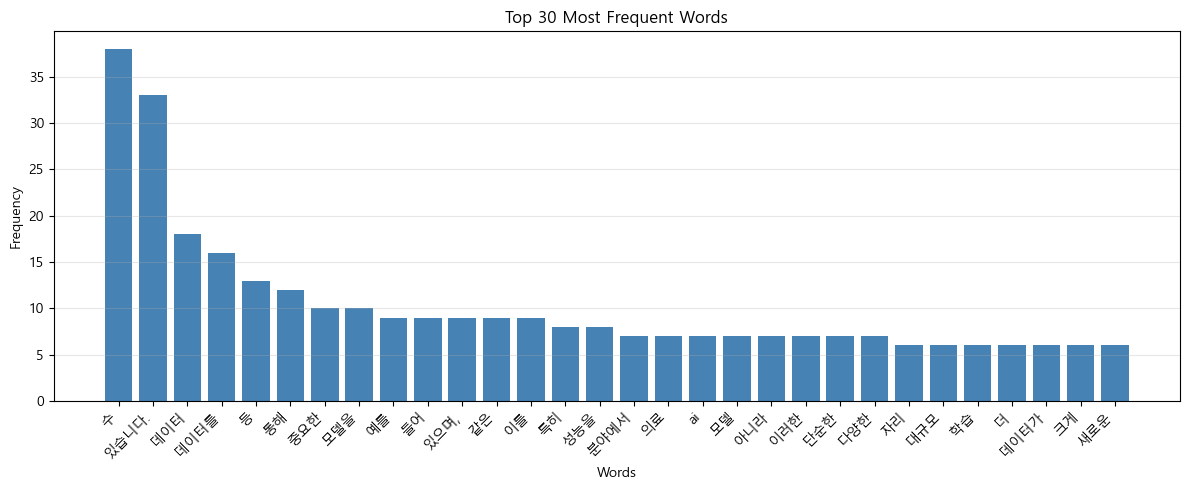

In [15]:
# 상위 단어 빈도 막대 그래프
top_words = corpus_stats['word_frequencies'].most_common(30)
words, counts = zip(*top_words)

plt.rcParams['font.family'] = 'Malgun Gothic'
# 한글 폰트 로드 (없으면 'NanumGothic'이나 'Dejavu Sans')

plt.figure(figsize=(12, 5))

plt.bar(range(len(words)), counts, color='steelblue')
plt.xticks(range(len(words)), words, rotation=45, ha='right')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 30 Most Frequent Words')
plt.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

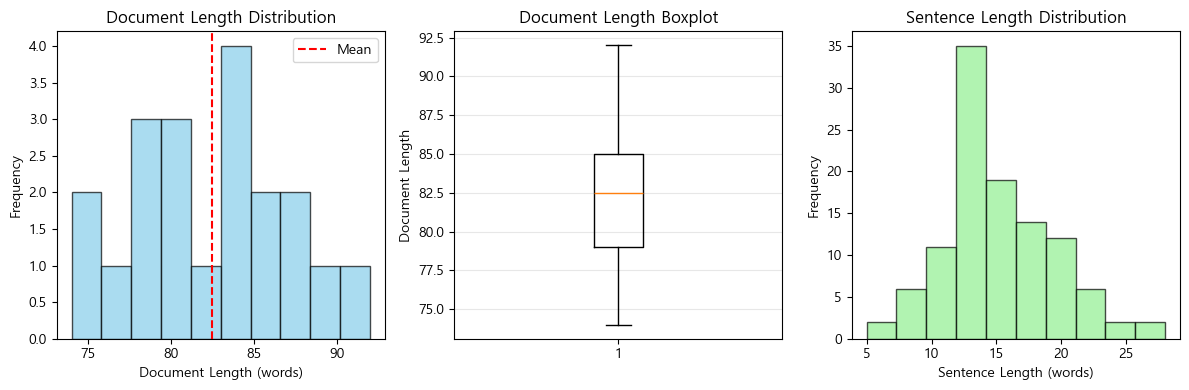

In [16]:
# 문서 길이 분포
plt.figure(figsize=(12, 4))

# 히스토그램
plt.subplot(1, 3, 1)
plt.hist(corpus_stats['doc_lengths'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Document Length (words)')
plt.ylabel('Frequency')
plt.title('Document Length Distribution')
plt.axvline(np.mean(corpus_stats['doc_lengths']), color='red', linestyle='--', label='Mean')
plt.legend()

# 박스플롯
plt.subplot(1, 3, 2)
plt.boxplot(corpus_stats['doc_lengths'], vert=True)
plt.ylabel('Document Length')
plt.title('Document Length Boxplot')
plt.grid(axis='y', alpha=0.3)

# 문장 길이 분포
if corpus_stats['sentence_lengths']:
    plt.subplot(1, 3, 3)
    plt.hist(corpus_stats['sentence_lengths'], bins=10, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.xlabel('Sentence Length (words)')
    plt.ylabel('Frequency')
    plt.title('Sentence Length Distribution')

plt.tight_layout()
plt.show()

## N-gram 분석

연속된 단어 패턴을 분석해보겠습니다.

In [17]:
def extract_ngrams(text, n=2):
    """N-gram 추출"""
    words = text.lower().split()
    ngrams = []
    
    for i in range(len(words) - n + 1):
        ngram = tuple(words[i:i+n])
        ngrams.append(ngram)
    
    return ngrams

def analyze_ngrams(documents, n_range=(2, 3)):
    """N-gram 빈도 분석"""
    ngram_stats = {}
    
    for n in range(n_range[0], n_range[1] + 1):
        all_ngrams = []
        
        for doc in documents:
            ngrams = extract_ngrams(doc, n)
            all_ngrams.extend(ngrams)
        
        ngram_freq = Counter(all_ngrams)
        ngram_stats[f'{n}-gram'] = ngram_freq.most_common(10)
    
    return ngram_stats

# N-gram 분석
ngram_results = analyze_ngrams(documents)

print("=== N-gram 분석 결과 ===")
for ngram_type, top_ngrams in ngram_results.items():
    print(f"\n{ngram_type} 상위 10개:")
    for ngram, freq in top_ngrams[:5]:  # 상위 5개만 표시
        ngram_str = ' '.join(ngram)
        print(f"  '{ngram_str}': {freq}회")

=== N-gram 분석 결과 ===

2-gram 상위 10개:
  '수 있습니다.': 16회
  '예를 들어': 9회
  '있습니다. 예를': 7회
  '등 다양한': 5회
  '수 있어': 5회

3-gram 상위 10개:
  '있습니다. 예를 들어': 7회
  '수 있습니다. 예를': 6회
  '자리 잡고 있습니다.': 2회
  '산업 전반에 걸쳐': 2회
  '분석 등 수많은': 2회


## 단어 동시 출현 행렬 (Co-occurrence Matrix)

단어들이 함께 나타나는 패턴을 분석합니다.

In [18]:
def build_cooccurrence_matrix(documents, window_size=2):
    """단어 동시 출현 행렬 구축"""
    vocab = set()
    for doc in documents:
        vocab.update(doc.lower().split())
    
    vocab = sorted(vocab)
    vocab_idx = {word: i for i, word in enumerate(vocab)}
    
    # 동시 출현 행렬 초기화
    cooc_matrix = np.zeros((len(vocab), len(vocab)))
    
    for doc in documents:
        words = doc.lower().split()
        
        for i, word1 in enumerate(words):
            for j in range(max(0, i - window_size), min(len(words), i + window_size + 1)):
                if i != j:
                    word2 = words[j]
                    idx1 = vocab_idx[word1]
                    idx2 = vocab_idx[word2]
                    cooc_matrix[idx1][idx2] += 1
    
    return cooc_matrix, vocab

# 동시 출현 행렬 생성
cooc_matrix, vocab = build_cooccurrence_matrix(documents[:3])  # 처음 3개 문서만

print(f"동시 출현 행렬 크기: {cooc_matrix.shape}")
print(f"어휘 크기: {len(vocab)}")

# 특정 단어와 자주 함께 나타나는 단어 찾기
target_word = '데이터'
if target_word in vocab:
    target_idx = vocab.index(target_word)
    cooc_scores = cooc_matrix[target_idx]
    
    # 상위 5개 공출현 단어
    top_indices = np.argsort(cooc_scores)[-5:][::-1]
    
    print(f"\n'{target_word}'와 자주 함께 나타나는 단어:")
    for idx in top_indices:
        if cooc_scores[idx] > 0:
            print(f"  {vocab[idx]}: {int(cooc_scores[idx])}회")

동시 출현 행렬 크기: (217, 217)
어휘 크기: 217

'데이터'와 자주 함께 나타나는 단어:
  하며,: 1회
  의사결정을: 1회
  자동차의: 1회
  처리와: 1회
  파이썬은: 1회


## 문서 유사도 분석

TF-IDF를 활용한 문서 간 유사도를 계산합니다.

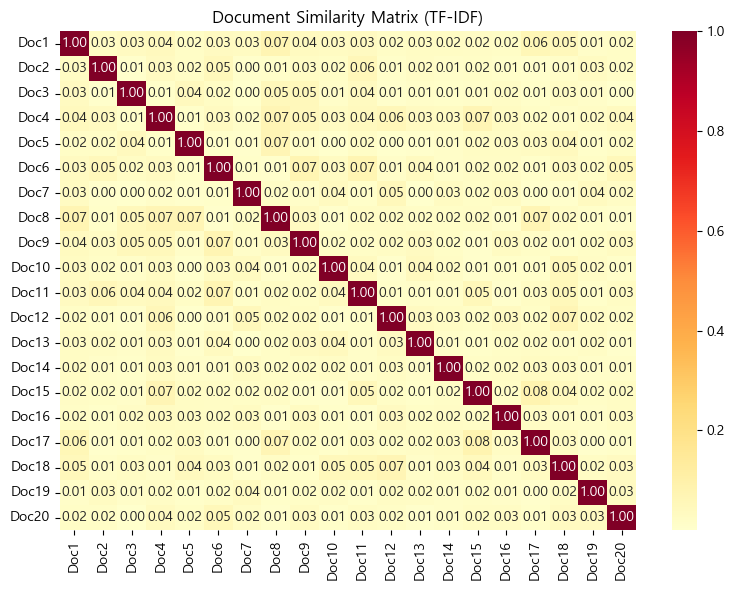


=== 가장 유사한 문서 쌍 ===
문서15 - 문서17: 0.081
  문서15: 퓨샷 러닝은 소량의 학습 데이터만으로도 모델이 새로운 작업을 학습할 수 있게 하는 기술입니...
  문서17: 생성형 AI는 단순히 기존 데이터를 분석하는 수준을 넘어 새로운 콘텐츠를 만들어내는 인공지...

문서1 - 문서8: 0.074
  문서1: 인공지능과 머신러닝은 현대 기술의 핵심으로 자리 잡고 있습니다. 단순히 연구실에서의 실험을...
  문서8: 컴퓨터 비전은 이미지와 비디오 데이터를 분석하고 이해하는 인공지능 분야입니다. 사람의 시각...

문서6 - 문서11: 0.073
  문서6: 데이터 전처리는 머신러닝 프로젝트의 성패를 가르는 가장 중요한 과정 중 하나입니다. 흔히 ...
  문서11: AutoML은 머신러닝 모델 개발을 자동화하여 전문가가 아니어도 AI를 활용할 수 있도록 ...



In [19]:
def cosine_similarity(v1, v2):
    """코사인 유사도 계산"""
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    
    if norm_v1 == 0 or norm_v2 == 0:
        return 0
    
    return dot_product / (norm_v1 * norm_v2)

def calculate_document_similarity(tfidf_matrix):
    """문서 간 유사도 행렬 계산"""
    n_docs = tfidf_matrix.shape[0]
    similarity_matrix = np.zeros((n_docs, n_docs))
    
    for i in range(n_docs):
        for j in range(n_docs):
            similarity_matrix[i][j] = cosine_similarity(
                tfidf_matrix[i], tfidf_matrix[j]
            )
    
    return similarity_matrix

# 문서 유사도 계산
doc_similarity = calculate_document_similarity(tfidf_matrix)

# 히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(doc_similarity, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f"Doc{i+1}" for i in range(len(documents))],
            yticklabels=[f"Doc{i+1}" for i in range(len(documents))])
plt.title('Document Similarity Matrix (TF-IDF)')
plt.tight_layout()
plt.show()

# 가장 유사한 문서 쌍 찾기
similarity_pairs = []
for i in range(len(documents)):
    for j in range(i+1, len(documents)):
        similarity_pairs.append((i, j, doc_similarity[i][j]))

similarity_pairs.sort(key=lambda x: x[2], reverse=True)

print("\n=== 가장 유사한 문서 쌍 ===")
for i, j, sim in similarity_pairs[:3]:
    print(f"문서{i+1} - 문서{j+1}: {sim:.3f}")
    print(f"  문서{i+1}: {documents[i][:50]}...")
    print(f"  문서{j+1}: {documents[j][:50]}...\n")

## 실전 프로젝트: 텍스트 분류를 위한 특징 추출

텍스트 분류에 사용할 수 있는 다양한 특징을 추출해보겠습니다.

In [22]:
features_df.corr()

,word_count,char_count,avg_word_length,sentence_count,upper_words,number_count,punctuation_count,unique_word_ratio,tech_keyword_count
word_count,1.000000,0.616110,-0.631644,0.359557,-0.239664,-0.099009,0.164185,-0.279585,-0.013417
char_count,0.616110,1.000000,0.220413,0.523764,0.095122,0.193959,0.427016,0.022141,0.024276
avg_word_length,-0.631644,0.220413,1.000000,0.055024,0.393410,0.297548,0.199445,0.374084,0.041537
sentence_count,0.359557,0.523764,0.055024,1.000000,-0.308665,-0.098513,0.138097,-0.297991,0.156174
upper_words,-0.239664,0.095122,0.393410,-0.308665,1.000000,0.266222,0.284294,0.135608,-0.008854
number_count,-0.099009,0.193959,0.297548,-0.098513,0.266222,1.000000,0.353778,0.339693,-0.059343
punctuation_count,0.164185,0.427016,0.199445,0.138097,0.284294,0.353778,1.000000,0.245182,-0.027133
unique_word_ratio,-0.279585,0.022141,0.374084,-0.297991,0.135608,0.339693,0.245182,1.000000,-0.027970
tech_keyword_count,-0.013417,0.024276,0.041537,0.156174,-0.008854,-0.059343,-0.027133,-0.027970,1.000000


In [20]:
class TextFeatureExtractor:
    """텍스트 특징 추출기"""
    
    def extract_features(self, text):
        """다양한 텍스트 특징 추출"""
        features = {}
        
        # 기본 통계
        words = text.split()
        features['word_count'] = len(words)
        features['char_count'] = len(text)
        features['avg_word_length'] = np.mean([len(w) for w in words]) if words else 0
        
        # 문장 통계
        sentences = re.split(r'[.!?]+', text)
        features['sentence_count'] = len([s for s in sentences if s.strip()])
        
        # 특수 패턴
        features['upper_words'] = len([w for w in words if w.isupper()])
        features['number_count'] = len(re.findall(r'\d+', text))
        features['punctuation_count'] = len(re.findall(r'[.,!?;:]', text))
        
        # 어휘 다양성
        unique_words = set(w.lower() for w in words)
        features['unique_word_ratio'] = len(unique_words) / len(words) if words else 0
        
        # 키워드 특징
        tech_keywords = ['AI', '머신러닝', '딥러닝', '데이터', '파이썬', '자연어처리']
        features['tech_keyword_count'] = sum(1 for kw in tech_keywords if kw.lower() in text.lower())
        
        return features
    
    def extract_batch(self, documents):
        """여러 문서의 특징 추출"""
        all_features = []
        for doc in documents:
            features = self.extract_features(doc)
            all_features.append(features)
        return pd.DataFrame(all_features)

# 특징 추출
extractor = TextFeatureExtractor()
features_df = extractor.extract_batch(documents)

print("=== 추출된 텍스트 특징 ===")
print(features_df.round(2))

# 특징 상관관계
correlation = features_df.corr()
print("\n=== 특징 간 상관관계 (상위 5개) ===")
corr_pairs = []
for i in range(len(correlation.columns)):
    for j in range(i+1, len(correlation.columns)):
        corr_pairs.append((
            correlation.columns[i],
            correlation.columns[j],
            correlation.iloc[i, j]
        ))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for feat1, feat2, corr in corr_pairs[:5]:
    print(f"{feat1} - {feat2}: {corr:.3f}")

=== 추출된 텍스트 특징 ===
    word_count  char_count  avg_word_length  sentence_count  upper_words  \
0           85         347             3.09               5            2   
1           79         377             3.78               6            0   
2           81         365             3.52               5            2   
3           92         368             3.01               5            1   
4           77         360             3.69               5            7   
5           84         356             3.25               6            0   
6           79         348             3.42               6            1   
7           79         344             3.37               5            4   
8           88         377             3.30               6            0   
9           80         353             3.42               5            7   
10          84         381             3.55               6            5   
11          85         351             3.14               5          

## 학습 내용 정리

### 핵심 텍스트 변환 기법

| 기법 | 설명 | 사용 시기 |
|------|------|----------|
| BOW | 단어 출현 횟수 벡터 | 간단한 분류, 기초 분석 |
| TF-IDF | 단어 중요도 반영 벡터 | 문서 검색, 키워드 추출 |
| N-gram | 연속 단어 패턴 | 구문 분석, 언어 모델 |
| Co-occurrence | 단어 동시 출현 | 단어 관계 분석 |

### 주요 통계 지표

| 지표 | 의미 | 계산 방법 |
|------|------|----------|
| 어휘 다양성 | 텍스트 풍부도 | 고유단어수/총단어수 |
| Zipf's Law | 단어 분포 법칙 | 순위-빈도 로그 관계 |
| 코사인 유사도 | 문서 유사성 | 벡터 내적/노름곱 |
| TF | 단어 빈도 | 단어수/문서길이 |
| IDF | 역문서 빈도 | log(총문서수/포함문서수) |

### 실습 완료 체크리스트

✓ Bag of Words (BOW) 구현  
✓ TF-IDF 계산 및 적용  
✓ 텍스트 통계 분석  
✓ 단어 빈도 시각화  
✓ N-gram 분석  
✓ 문서 유사도 계산  
✓ 텍스트 특징 추출